<a href="https://colab.research.google.com/github/AyaAbdElNaem/Deep_Learning/blob/main/Task_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-cymlk39x
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-cymlk39x
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.5.12.61975-py3-none-any.whl size=186932 sha256=502f5ef39e3cb913206f3f62a655337cb6ff910ec07215ff0bb6a4e474794ef0
  Stored in directory: /tmp/pip-ephem-wheel-cache-jmmvdrgs/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
import tensorflow_docs as tfdocs
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense

In [4]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a dictionary-like object to mimic the original boston dataset structure
# This is done to maintain compatibility with downstream code that might expect 'data' and 'target' attributes
boston = type('BostonDataset', (object,), {})
boston.data = data
boston.target = target
boston.feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]
boston.DESCR = """Boston house prices dataset (fetched from original source)"""

features = np.array(boston.data)
target = np.array(boston.target)

In [5]:
n_training_samples = features.shape[0]
n_dim = features.shape[1]

print('The dataset has', n_training_samples, 'training samples.')
print('The dataset has', n_dim, 'features.')

The dataset has 506 training samples.
The dataset has 13 features.


In [6]:
def normalize(dataset):
    mu = np.mean(dataset, axis = 0)
    sigma = np.std(dataset, axis = 0)
    return (dataset - mu)/sigma

In [7]:
features_norm = normalize(features)

In [8]:
np.random.seed(42)
rnd = np.random.rand(len(features_norm)) < 0.8

train_x = features_norm[rnd]
train_y = target[rnd]
dev_x = features_norm[~rnd]
dev_y = target[~rnd]

print(train_x.shape)
print(train_y.shape)
print(dev_x.shape)
print(dev_y.shape)

(399, 13)
(399,)
(107, 13)
(107,)


Try to determine which architecture (number of layers and number of neurons) is not overfitting the Boston dataset. When the network starts overfitting? Which network would give a good result?

#Regression Model
Because Im Predicting a price (number)

In [9]:
# def build_model(opt):
#   # create model
# 	model = keras.Sequential()
# 	model.add(layers.Dense(15, input_dim = 13, activation = 'relu')) # add first hidden layer and set input dimensions
# 	model.add(layers.Dense(1)) # add output layer
# 	# compile model
# 	model.compile(loss = 'mse', optimizer = opt, metrics = ['mae'])
# 	return model

In [10]:
# model = build_model(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [11]:
def build_model1_3(opt):
    model = keras.Sequential([
        # 1. طبقة المدخلات (The Input Layer)
        # هنا نخبر الموديل أننا سندخل 13 رقماً لكل عينة (بيانات بوسطن)
        layers.Input(shape=(13,)),

        # 2. الطبقات المخفية (Hidden Layers)
        # الآن هذه الطبقات تركز فقط على "التعلم" ولا تشغل بالها بأبعاد المدخلات
        layers.Dense(3, activation='relu'),

        # 3. طبقة المخرجات (Output Layer)
        # نيرون واحد للتنبؤ بالسعر
        layers.Dense(1)
    ])

    # تجميع الموديل
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [12]:
model1_3 = build_model1_3(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [13]:
model1_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
EPOCHS = 500

history1_3 = model1_3.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])

AttributeError: module 'tensorflow_docs' has no attribute 'modeling'

In [61]:
hist = pd.DataFrame(history1_3.history)
hist['epoch'] = history1_3.epoch
hist.tail()

,loss,mae,epoch
995,6.038267,1.748643,995
996,6.036870,1.748227,996
997,6.034221,1.747564,997
998,6.032240,1.747020,998
999,6.030429,1.746782,999


In [62]:
test_loss, test_mae = model1_3.evaluate(dev_x, dev_y, verbose = 0)
print(f'Mean Absolute Error on test set: ${test_mae:.2f}k')

Mean Absolute Error on test set: $2.69k


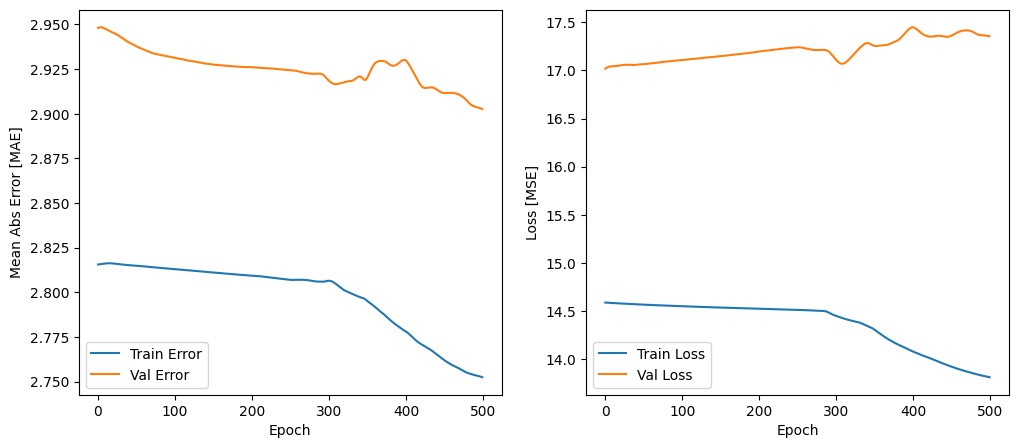

In [80]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(12, 5))

    # الرسم الخاص بـ Mean Absolute Error
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MAE]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
    plt.legend()

    # الرسم الخاص بـ Loss
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss [MSE]')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
    plt.legend()

    plt.show()

# استدعاء الدالة لرؤية النتائج
plot_history(history1_3)

In [72]:
def build_model1_5(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [73]:
model1_5 = build_model1_5(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [74]:
model1_5.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76 (304.00 B)

 Trainable params: 76 (304.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
EPOCHS = 500

history1_5 = model1_5.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])


Epoch: 0, loss:12.9072,  mae:2.6581,  val_loss:15.5948,  val_mae:3.0819,  
....................................................................................................
Epoch: 100, loss:12.7119,  mae:2.6336,  val_loss:15.6695,  val_mae:3.0583,  
....................................................................................................
Epoch: 200, loss:12.5464,  mae:2.6115,  val_loss:15.7080,  val_mae:3.0376,  
....................................................................................................
Epoch: 300, loss:12.4114,  mae:2.5950,  val_loss:15.7819,  val_mae:3.0165,  
....................................................................................................
Epoch: 400, loss:12.2656,  mae:2.5764,  val_loss:15.8347,  val_mae:3.0005,  
....................................................................................................

In [1]:
plot_history(history1_5)

NameError: name 'plot_history' is not defined